# 🎁 Open EDA Tooling Treats

```
Copyright 2021 Google LLC.
SPDX-License-Identifier: Apache-2.0
```

Context: https://twitter.com/proppy/status/1466020384063430657

## 🍬 Treat #1: EDA Conda Packages & Notebooks

The [conda-eda](https://github.com/hdl/conda-eda) project maintains a collection of conda packages recipes. Those package can be used to easily bootstrap EDA environments in Jupyter and Colab notebooks.

This notebook shows how to lint Verilog cells and plot the simulated waveforms for a simple 4-bits counter design.

### Install packages

Install packages from the `LiteX-Hub` [channel](https://anaconda.org/LiteX-Hub/repo); also install older packages from the `SymbiFlow` channel, to get better compat with colab: see [conda-eda#146](https://github.com/hdl/conda-eda/issues/146).

In [1]:
!curl -O https://repo.anaconda.com/miniconda/Miniconda3-py37_4.10.3-Linux-x86_64.sh
!bash Miniconda3-py37_4.10.3-Linux-x86_64.sh -b -f -p miniconda-eda/
!miniconda-eda/bin/conda install --yes -c LiteX-Hub iverilog
!miniconda-eda/bin/conda install --yes -c SymbiFlow verible

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.9M  100 84.9M    0     0   108M      0 --:--:-- --:--:-- --:--:--  108M
PREFIX=/content/miniconda-eda
Unpacking payload ...
Solving environment: / - \ done

## Package Plan ##

  environment location: /content/miniconda-eda

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - _openmp_mutex==4.5=1_gnu
    - brotlipy==0.7.0=py37h27cfd23_1003
    - ca-certificates==2021.7.5=h06a4308_1
    - certifi==2021.5.30=py37h06a4308_0
    - cffi==1.14.6=py37h400218f_0
    - chardet==4.0.0=py37h06a4308_1003
    - conda-package-handling==1.7.3=py37h27cfd23_1
    - conda==4.10.3=py37h06a4308_0
    - cryptography==3.4.7=py37hd23ed53_0
    - idna==2.10=pyhd3eb1b0_0
    - ld_impl_linux-64==2.35.1=h7274673_9
    - libffi==3.3=he6710b0_2
    - libgcc-ng==9.3.0=h5101ec6_17
    - libgomp==9.3.0=h5101ec6_17
    - libstdcxx-ng==9.3.0=

### Lint and simulate Verilog cells

Use the `%%bash` magic to lint the content of the cell with [Verible](https://github.com/chipsalliance/verible) and simulate the test bench using [Icarus Verilog](http://iverilog.icarus.com/).


In [2]:
%%bash -c 'source miniconda-eda/bin/activate; cat > counter.v; verible-verilog-lint counter.v && iverilog counter.v && vvp a.out'

module counter(input clk, input rst, output reg[3:0] out);
  always @ (posedge clk) begin
    if (rst)
      out <= 0;
    else
      out <= out + 1;
  end
endmodule

module counter_tb;
  reg clk;
  reg rst;

  wire [3:0] out;

  counter c1(.clk(clk), .rst(rst), .out(out));

  always #1 clk = !clk;

  initial begin
    $dumpfile("test.vcd");
    $dumpvars(0,counter_tb);
    clk <= 0;
    rst <= 1;
    #1  rst <= 0;
    #11 rst <= 1;
    #1  rst <= 0;
    #51 $finish;
  end
endmodule

VCD info: dumpfile test.vcd opened for output.
counter.v:29: $finish called at 64 (1s)


### Plot VCD waveforms

Use [vcdvcd](https://pypi.org/project/vcdvcd/) VCD parser to plot the simulated waveform using regular matplotlib functions.

In [3]:
!python -m pip install vcdvcd

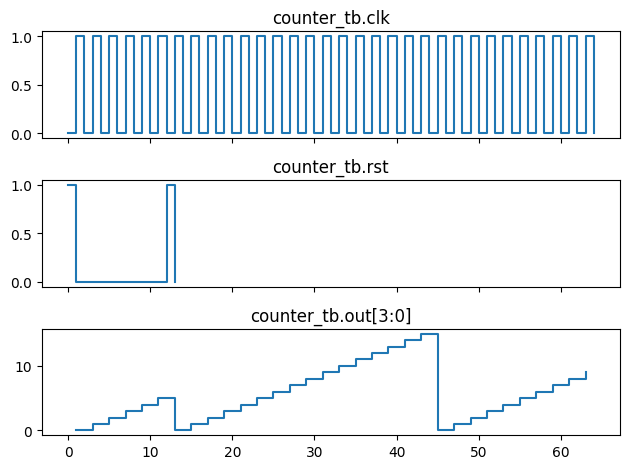

In [4]:
from vcdvcd import VCDVCD

vcd = VCDVCD('test.vcd')
import matplotlib.pyplot as plt
signals = ['counter_tb.clk', 'counter_tb.rst', 'counter_tb.out[3:0]']
f, plots = plt.subplots(len(signals), 1, sharex=True)
for s, plt in zip(signals, plots):
  x, y = zip(*vcd[s].tv)
  y = [int(n, 2) if n != 'x' else None for n in y]
  plt.step(x, y, label=s, where = 'post')
  plt.set_title(s)
f.tight_layout()
f.show()

## 🍡 Treat #2: Yosys synthesis and circuit drawing

[Yosys](https://yosyshq.net/yosys/) is a versatile tool to synthesize HDL designs to netlist and map them to the underlying technology target.

This notebook shows how to synthesize a simple 1-bit adder Verilog design to different levels of technology abstraction (standard logic gates, CMOS, LUTs, discrete ICs) and draw the underlying circuit diagrams.

### Install packages

Install packages from the `LiteX-Hub` and `SymbiFlow` channel.

In [5]:
!curl -O https://repo.anaconda.com/miniconda/Miniconda3-py37_4.10.3-Linux-x86_64.sh
!bash Miniconda3-py37_4.10.3-Linux-x86_64.sh -b -f -p miniconda-synth/
!miniconda-synth/bin/conda install --yes -c LiteX-Hub yosys
!miniconda-synth/bin/conda install --yes -c SymbiFlow verible

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.9M  100 84.9M    0     0  57.7M      0  0:00:01  0:00:01 --:--:-- 57.7M
PREFIX=/content/miniconda-synth
Unpacking payload ...
Solving environment: / - \ done

## Package Plan ##

  environment location: /content/miniconda-synth

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - _openmp_mutex==4.5=1_gnu
    - brotlipy==0.7.0=py37h27cfd23_1003
    - ca-certificates==2021.7.5=h06a4308_1
    - certifi==2021.5.30=py37h06a4308_0
    - cffi==1.14.6=py37h400218f_0
    - chardet==4.0.0=py37h06a4308_1003
    - conda-package-handling==1.7.3=py37h27cfd23_1
    - conda==4.10.3=py37h06a4308_0
    - cryptography==3.4.7=py37hd23ed53_0
    - idna==2.10=pyhd3eb1b0_0
    - ld_impl_linux-64==2.35.1=h7274673_9
    - libffi==3.3=he6710b0_2
    - libgcc-ng==9.3.0=h5101ec6_17
    - libgomp==9.3.0=h5101ec6_17
    - libstdcxx-ng==9.

### Lint Verilog

Use the `%%bash` magic to the `adder` Verilog module with [Verible](https://github.com/chipsalliance/verible).

In [6]:
%%bash -c 'source miniconda-synth/bin/activate; cat > adder.v; verible-verilog-lint adder.v'

module adder(
  input wire a,
  input wire b,
  output wire [1:0] out
);
  assign out = a + b;
endmodule

### Synth design

Synthesize design netlist: map to a single `add` cell.

In [7]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv adder.v
hierarchy -top adder

proc; opt

opt_clean
show -format dot -prefix synth_design
stat


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: adder.v
Parsing SystemVerilog input from `adder.v' to AST representation.
Storing AST representation for module `$abstract\adder'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\adder'.
Generating RTLIL representation for module `\adder'.

3.1. Analyzing design hierarchy..
Top module:  \adder

3.2. Analyzing design hierarchy..
Top module:  \adder
Removing unused module `$abstract\adder'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing PROC pass (convert processes to netlists).

4.1. Executing PROC_CLEAN pass (remove empty switches from decision trees).
Cleaned up 0 empty switches.

4.2. Executing PROC_RMDEAD pass (remove dead branches from decision trees).
Removed a total of 0 dead cases.

4.3. Executing PROC_PRUNE pass (remove redundant assignments in processes).
Removed 0 redundant assignme

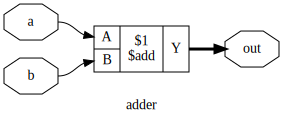

In [8]:
import graphviz
graphviz.Source.from_file('synth_design.dot')

### Synth gates

Synthesize gate netlist: map to built-in `XOR` and `AND` logic gates.

In [9]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv adder.v
hierarchy -top adder

proc; opt
techmap; opt

opt_clean
show -format dot -prefix synth_gate
stat


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: adder.v
Parsing SystemVerilog input from `adder.v' to AST representation.
Storing AST representation for module `$abstract\adder'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\adder'.
Generating RTLIL representation for module `\adder'.

3.1. Analyzing design hierarchy..
Top module:  \adder

3.2. Analyzing design hierarchy..
Top module:  \adder
Removing unused module `$abstract\adder'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing PROC pass (convert processes to netlists).

4.1. Executing PROC_CLEAN pass (remove empty switches from decision trees).
Cleaned up 0 empty switches.

4.2. Executing PROC_RMDEAD pass (remove dead branches from decision trees).
Removed a total of 0 dead cases.

4.3. Executing PROC_PRUNE pass (remove redundant assignments in processes).
Removed 0 redundant assignme

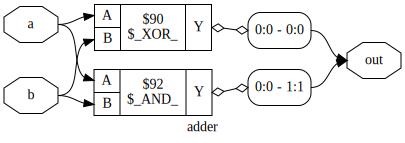

In [10]:
import graphviz
graphviz.Source.from_file('synth_gate.dot')

### Synth FPGA

Synthesize FPGA netlist: map to `IC40` `LUT` gates using a builtin synthesis script.

In [11]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv adder.v
hierarchy -top adder

synth_ice40

opt_clean
show -format dot -prefix synth_ice40


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: adder.v
Parsing SystemVerilog input from `adder.v' to AST representation.
Storing AST representation for module `$abstract\adder'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\adder'.
Generating RTLIL representation for module `\adder'.

3.1. Analyzing design hierarchy..
Top module:  \adder

3.2. Analyzing design hierarchy..
Top module:  \adder
Removing unused module `$abstract\adder'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing SYNTH_ICE40 pass.

4.1. Executing Verilog-2005 frontend: /content/miniconda-synth/bin/../share/yosys/ice40/cells_sim.v
Parsing Verilog input from `/content/miniconda-synth/bin/../share/yosys/ice40/cells_sim.v' to AST representation.
Generating RTLIL representation for module `\SB_IO'.
Generating RTLIL representation for module `\SB_GB_IO'.
Generating RTLIL repre

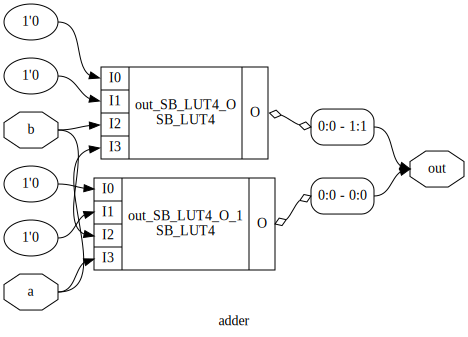

In [12]:
import graphviz
graphviz.Source.from_file('synth_ice40.dot')

### Synth CMOS

Synthesize CMOS netlist: map to `NOR` and `NOT` gates using CMOS technology mapping from `yosys examples.

In [13]:
!curl --silent -L https://github.com/YosysHQ/yosys/archive/refs/tags/yosys-0.11.tar.gz | tar xvzf - yosys-yosys-0.11/examples/cmos --strip-components=2

yosys-yosys-0.11/examples/cmos/
yosys-yosys-0.11/examples/cmos/.gitignore
yosys-yosys-0.11/examples/cmos/README
yosys-yosys-0.11/examples/cmos/cmos_cells.lib
yosys-yosys-0.11/examples/cmos/cmos_cells.sp
yosys-yosys-0.11/examples/cmos/cmos_cells.v
yosys-yosys-0.11/examples/cmos/cmos_cells_digital.sp
yosys-yosys-0.11/examples/cmos/counter.v
yosys-yosys-0.11/examples/cmos/counter.ys
yosys-yosys-0.11/examples/cmos/counter_digital.ys
yosys-yosys-0.11/examples/cmos/counter_tb.gtkw
yosys-yosys-0.11/examples/cmos/counter_tb.v
yosys-yosys-0.11/examples/cmos/testbench.sh
yosys-yosys-0.11/examples/cmos/testbench.sp
yosys-yosys-0.11/examples/cmos/testbench_digital.sh
yosys-yosys-0.11/examples/cmos/testbench_digital.sp


In [14]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv adder.v
hierarchy -top adder

read -sv -lib cmos/cmos_cells.v
synth
dfflibmap -liberty cmos/cmos_cells.lib
abc -liberty cmos/cmos_cells.lib

opt_clean
show -format dot -prefix synth_cmos
stat -liberty cmos/cmos_cells.lib


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: adder.v
Parsing SystemVerilog input from `adder.v' to AST representation.
Storing AST representation for module `$abstract\adder'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\adder'.
Generating RTLIL representation for module `\adder'.

3.1. Analyzing design hierarchy..
Top module:  \adder

3.2. Analyzing design hierarchy..
Top module:  \adder
Removing unused module `$abstract\adder'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing Verilog-2005 frontend: cmos/cmos_cells.v
Parsing SystemVerilog input from `cmos/cmos_cells.v' to AST representation.
Storing AST representation for module `$abstract\BUF'.
Storing AST representation for module `$abstract\NOT'.
Storing AST representation for module `$abstract\NAND'.
Storing AST representation for module `$abstract\NOR'.
Storing AST representation

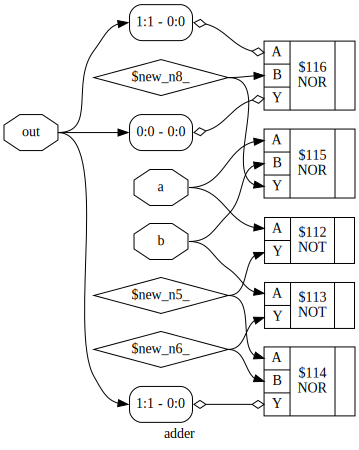

In [15]:
import graphviz
graphviz.Source.from_file('synth_cmos.dot')

### Synth 74xx

Synthesize 74xx netlist: map to `74AC08` a nd `74AC86` discrete gate ICs using community provided technology mapping.

In [16]:
!git clone https://github.com/Ravenslofty/74xx-liberty

Cloning into '74xx-liberty'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 238 (delta 59), reused 58 (delta 58), pack-reused 170 (from 1)
Receiving objects: 100% (238/238), 112.96 KiB | 4.18 MiB/s, done.
Resolving deltas: 100% (128/128), done.


In [17]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv adder.v
hierarchy -top adder

read -sv -lib 74xx-liberty/74_models.v
synth
abc -liberty 74xx-liberty/74ac.lib
dfflibmap -liberty 74xx-liberty/74ac.lib

opt_clean
show -format dot -prefix synth_74
stat -liberty 74xx-liberty/74ac.lib


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: adder.v
Parsing SystemVerilog input from `adder.v' to AST representation.
Storing AST representation for module `$abstract\adder'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\adder'.
Generating RTLIL representation for module `\adder'.

3.1. Analyzing design hierarchy..
Top module:  \adder

3.2. Analyzing design hierarchy..
Top module:  \adder
Removing unused module `$abstract\adder'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing Verilog-2005 frontend: 74xx-liberty/74_models.v
Parsing SystemVerilog input from `74xx-liberty/74_models.v' to AST representation.
Storing AST representation for module `$abstract\74HC85_1x1CMP4'.
Storing AST representation for module `$abstract\74AC283_1x1ADD4'.
Storing AST representation for module `$abstract\74AC377_8x1DFFE'.
Storing AST representation for mo

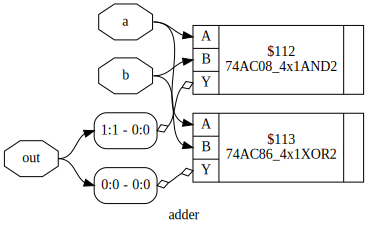

In [18]:
import graphviz
graphviz.Source.from_file('synth_74.dot')

## 🍫Treat #3 nextpnr and SVG floor map

[nextpnr](https://github.com/YosysHQ/nextpnr) is a vendor neutral place and route tool that support multiple FPGA architectures.

It takes [Yosys](https://yosyshq.net/yosys/) synthesis `JSON` output and attemps to place and wire the resulting cells on the target FPGA functional blocks.

This notebook shows the floor map of an `ICE40UP5K` with a simple 8-bit adder that occupies 19 LUTs, and a [Quadratic Polynomial  function from Project F](https://projectf.io/posts/multiplication-fpga-dsps/#quartic-polynomial) that occupies 86% of the available LUTs.

### Install packages

Install packages from the `LiteX-Hub` and `SymbiFlow` channel.

In [19]:
!curl -O https://repo.anaconda.com/miniconda/Miniconda3-py37_4.10.3-Linux-x86_64.sh
!bash Miniconda3-py37_4.10.3-Linux-x86_64.sh -b -f -p miniconda-pnr/
!miniconda-pnr/bin/conda install -y -c LiteX-Hub yosys nextpnr-ice40
!miniconda-pnr/bin/conda install --yes -c SymbiFlow verible

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.9M  100 84.9M    0     0  92.6M      0 --:--:-- --:--:-- --:--:-- 92.5M
PREFIX=/content/miniconda-pnr
Unpacking payload ...
Solving environment: / - \ done

## Package Plan ##

  environment location: /content/miniconda-pnr

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - _openmp_mutex==4.5=1_gnu
    - brotlipy==0.7.0=py37h27cfd23_1003
    - ca-certificates==2021.7.5=h06a4308_1
    - certifi==2021.5.30=py37h06a4308_0
    - cffi==1.14.6=py37h400218f_0
    - chardet==4.0.0=py37h06a4308_1003
    - conda-package-handling==1.7.3=py37h27cfd23_1
    - conda==4.10.3=py37h06a4308_0
    - cryptography==3.4.7=py37hd23ed53_0
    - idna==2.10=pyhd3eb1b0_0
    - ld_impl_linux-64==2.35.1=h7274673_9
    - libffi==3.3=he6710b0_2
    - libgcc-ng==9.3.0=h5101ec6_17
    - libgomp==9.3.0=h5101ec6_17
    - libstdcxx-ng==9.3.0=

### Place and Route 8-bit adder

In [20]:
%%bash -c 'source miniconda-pnr/bin/activate; cat > adder8.v; verible-verilog-lint adder8.v'

module adder8(
  input wire [7:0] a,
  input wire [7:0] b,
  output wire [7:0] out
);
  assign out = a + b;
endmodule

In [21]:
!miniconda-pnr/bin/yosys -p 'synth_ice40 -top adder8 -json adder8.json' adder8.v
!miniconda-pnr/bin/nextpnr-ice40 --up5k --json adder8.json --asc adder8.asc --placed-svg adder8_placed.svg


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2020  Claire Xenia Wolf <claire@yosyshq.com>         |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

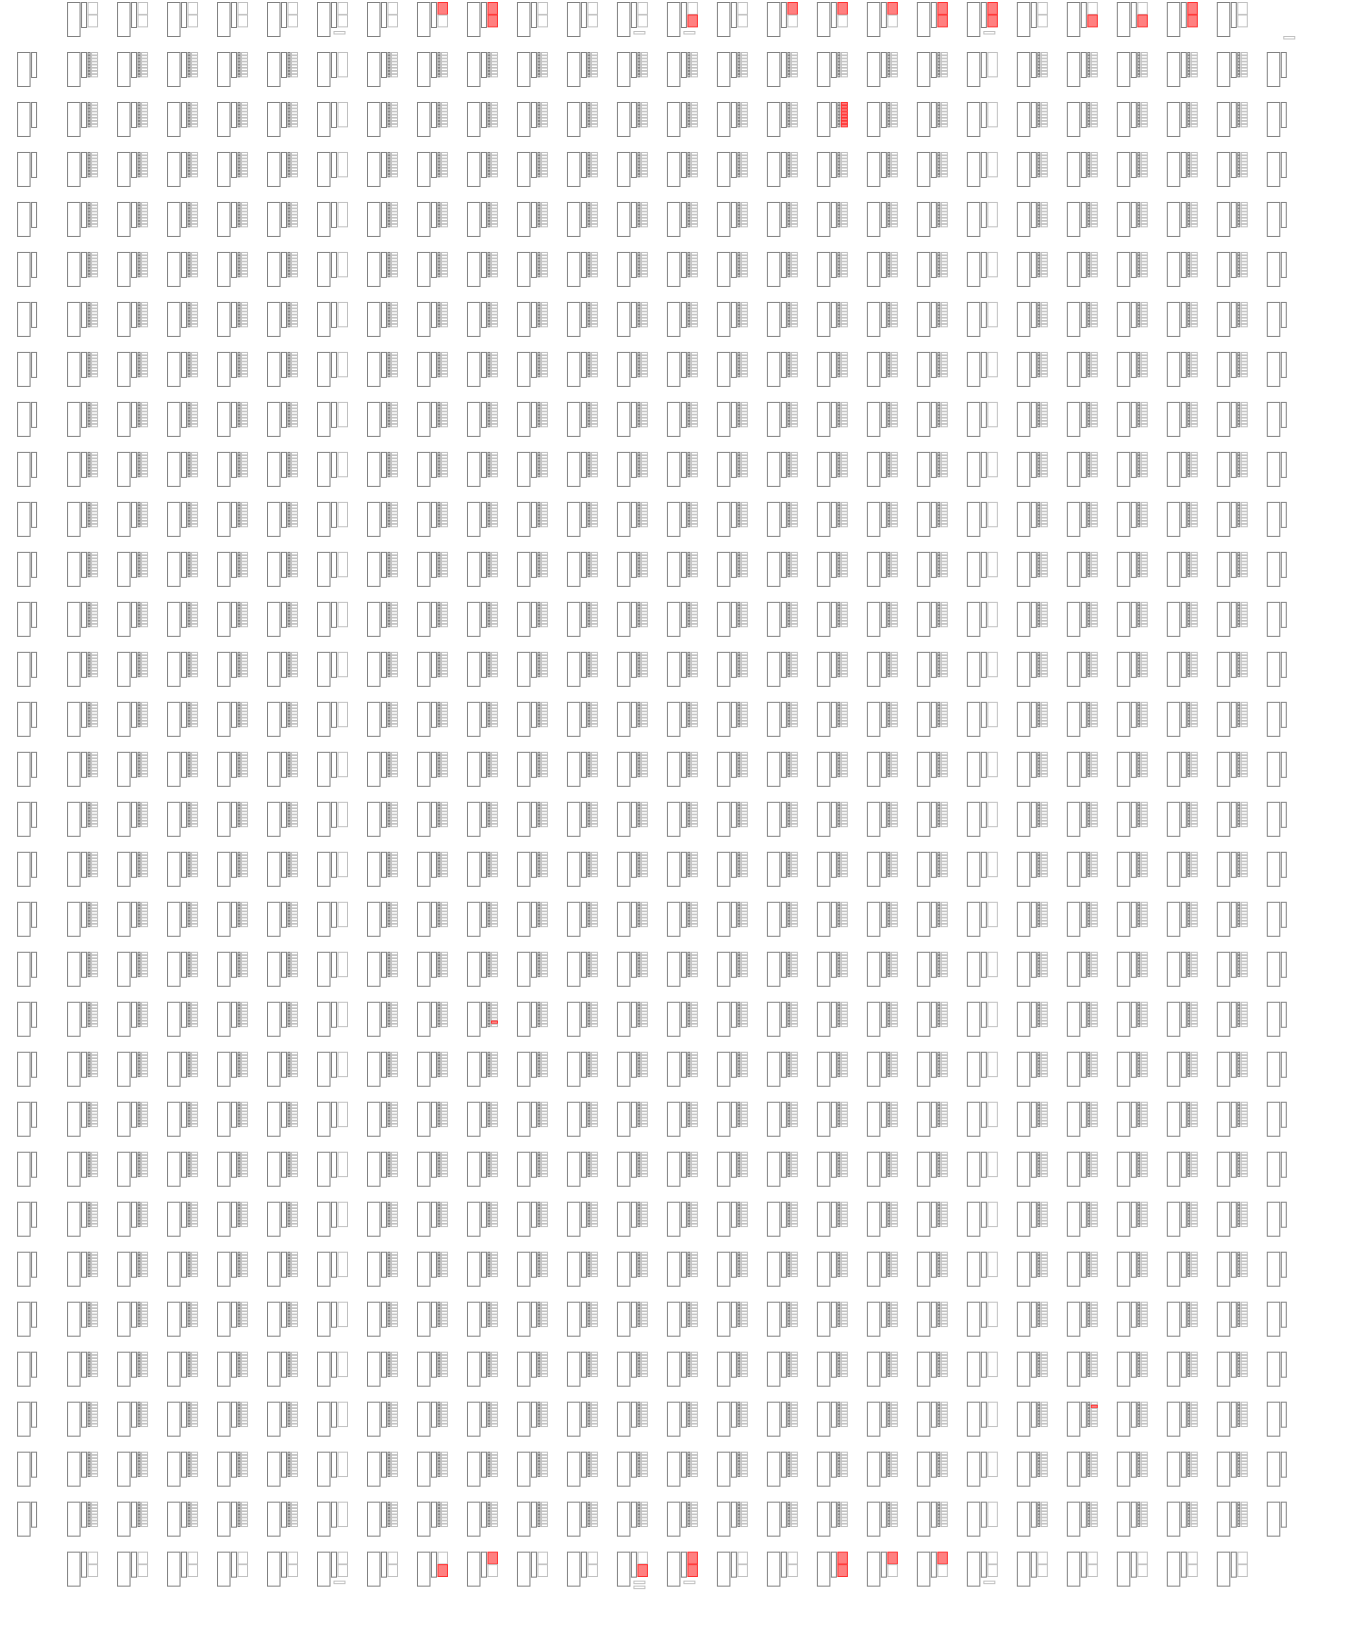

In [22]:
from IPython.display import SVG
SVG(filename='adder8_placed.svg')

### Place and Route 18-bit polynomial function

In [23]:
!git clone https://github.com/projf/projf-explore.git
# make it bigger!
!sed -i -e s/CORDW=8/CORDW=18/ projf-explore/maths/demo/func_polynomial.sv

Cloning into 'projf-explore'...
remote: Enumerating objects: 6759, done.
remote: Counting objects: 100% (521/521), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 6759 (delta 392), reused 293 (delta 278), pack-reused 6238 (from 4)
Receiving objects: 100% (6759/6759), 3.18 MiB | 18.73 MiB/s, done.
Resolving deltas: 100% (4576/4576), done.


In [24]:
!miniconda-pnr/bin/yosys -p 'synth_ice40 -top func_polynomial -json func_polynomial.json' projf-explore/maths/demo/func_polynomial.sv
!miniconda-pnr/bin/nextpnr-ice40 --up5k --json func_polynomial.json --asc func_polynomial.asc --placed-svg func_polynomial_placed.svg


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2020  Claire Xenia Wolf <claire@yosyshq.com>         |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

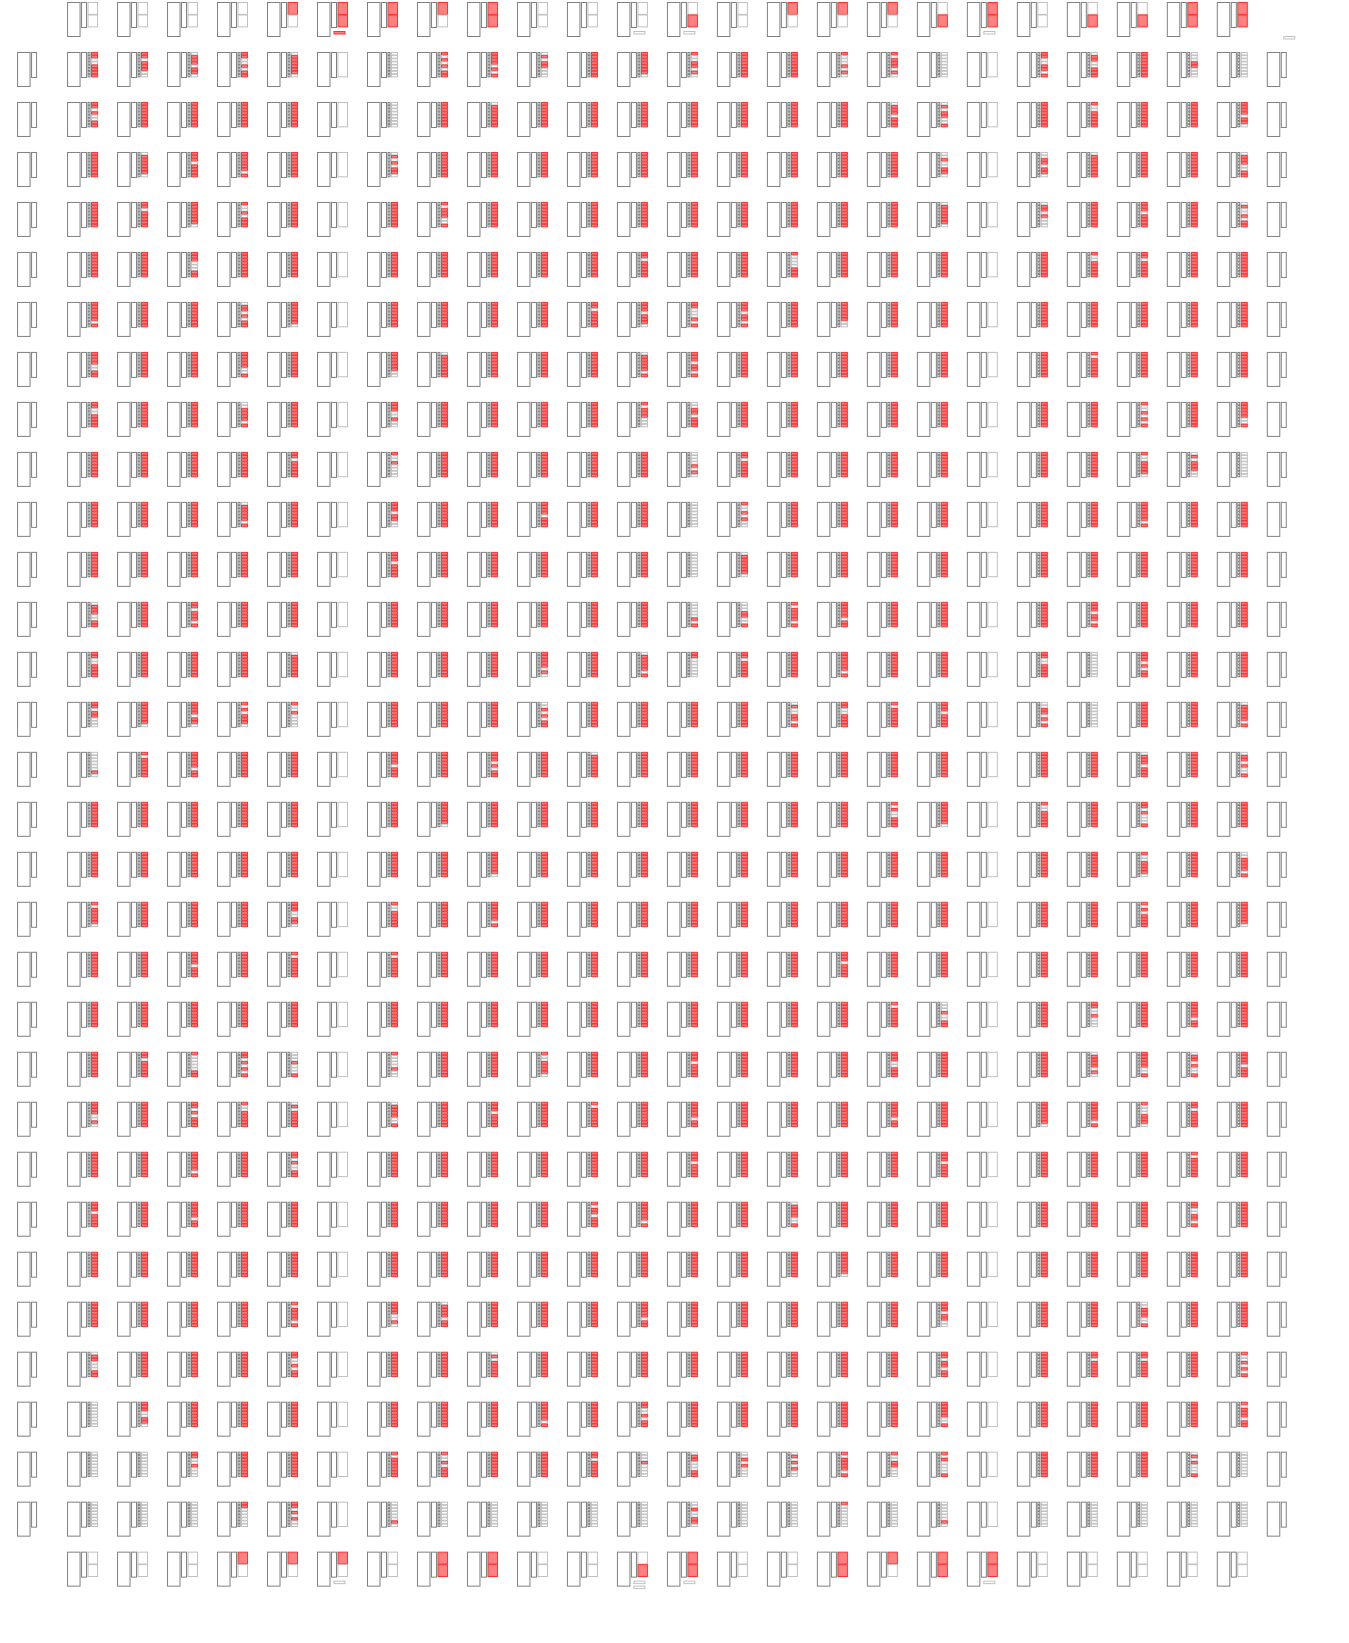

In [30]:
from IPython.display import SVG
SVG(filename='func_polynomial_placed.svg')